# 011 - Analise exploratoria

Este notebook gera tabelas e graficos simples para caracterizar as descricoes de itens fiscais antes dos experimentos de modelagem.

Análise feita sobre a base de dados crua.

In [43]:
from __future__ import annotations

import sys
import re
import os
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    source_dir = path / "src"
    if source_dir.exists():
        sys.path.append(str(source_dir))
        break
else:
    raise FileNotFoundError("Nao encontrei a pasta src nos diretorios pais.")

from nofis_classifier.paths import find_project_root

## Configuracao

In [44]:
DATASET_NAME = "items-notas-fiscais"
DESCRIPTION_TERMS = ("DESCRICAO", "PRODUTO", "SERVICO")
NCM_CODE_TERMS = ("CODIGO", "NCM", "SH")
NCM_TYPE_TERMS = ("NCM", "TIPO", "PRODUTO")
FISCAL_COLUMN_TERMS = {
    "serie": ("SERIE",),
    "natureza_operacao": ("NATUREZA", "OPERACAO"),
    "razao_social_emitente": ("RAZAO", "SOCIAL", "EMITENTE"),
    "consumidor_final": ("CONSUMIDOR", "FINAL"),
    "presenca_comprador": ("PRESENCA", "COMPRADOR"),
}
FISCAL_COLUMN_LABELS = {
    "serie": "SÉRIE",
    "natureza_operacao": "NATUREZA DA OPERAÇÃO",
    "razao_social_emitente": "RAZÃO SOCIAL EMITENTE",
    "consumidor_final": "CONSUMIDOR FINAL",
    "presenca_comprador": "PRESENÇA DO COMPRADOR",
}

def normalize_column_name(name: object) -> str:
    """Normalize column names for accent-insensitive matching."""
    text = unicodedata.normalize("NFKD", str(name))
    text = "".join(char for char in text if not unicodedata.combining(char))
    return text.upper()


def find_column(columns: pd.Index, required_terms: tuple[str, ...]) -> str:
    """Find a column containing all required terms after normalization."""
    normalized_terms = tuple(normalize_column_name(term) for term in required_terms)
    for column in columns:
        normalized_column = normalize_column_name(column)
        if all(term in normalized_column for term in normalized_terms):
            return str(column)
    raise KeyError(f"Nenhuma coluna encontrada para os termos {required_terms}.")


def clean_categorical_series(series: pd.Series) -> pd.Series:
    """Return a string series with blanks converted to missing values."""
    return series.astype("string").str.strip().replace("", pd.NA)


PROJECT_ROOT = find_project_root()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / DATASET_NAME
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / DATASET_NAME

pd.options.display.max_colwidth = 120
plt.style.use("default")

INTERIM_DIR, PROCESSED_DIR


(WindowsPath('C:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais'),
 WindowsPath('C:/Users/samue/Scripts/Nofis-Classifier/data/processed/items-notas-fiscais'))

## Carregar bases

A base processada esta consolidada por descricao normalizada e preserva a frequencia total. Os parquets intermediarios sao usados para medir volume mensal e proporcoes por mes.

In [45]:
processed_files = sorted(PROCESSED_DIR.glob("*.parquet"))
if not processed_files:
    raise FileNotFoundError(f"Nenhum parquet processado encontrado em {PROCESSED_DIR}.")

processed_path = processed_files[-1]
df_descriptions = pd.read_parquet(processed_path)

interim_files = sorted(INTERIM_DIR.glob("*.parquet"))
if not interim_files:
    raise FileNotFoundError(f"Nenhum parquet intermediario encontrado em {INTERIM_DIR}.")

monthly_frames = []
for parquet_file in interim_files:
    schema_columns = pd.Index(pq.read_schema(parquet_file).names)
    description_column = find_column(schema_columns, DESCRIPTION_TERMS)
    ncm_code_column = find_column(schema_columns, NCM_CODE_TERMS)
    fiscal_columns = {
        output_column: find_column(schema_columns, required_terms)
        for output_column, required_terms in FISCAL_COLUMN_TERMS.items()
    }
    source_columns = [description_column, ncm_code_column, *fiscal_columns.values()]
    frame = pd.read_parquet(parquet_file, columns=source_columns)
    frame = frame.rename(
        columns={
            description_column: "descricao_original",
            ncm_code_column: "codigo_ncm",
            **{source_column: output_column for output_column, source_column in fiscal_columns.items()},
        }
    )
    frame["competencia"] = parquet_file.stem
    monthly_frames.append(frame)

df_monthly = pd.concat(monthly_frames, ignore_index=True)

print(f"Base processada: {processed_path.relative_to(PROJECT_ROOT)}")
print(f"Descricoes unicas normalizadas: {len(df_descriptions):,}")
print(f"Itens representados na base processada: {df_descriptions['frequencia'].sum():,}")
print(f"Itens nos parquets intermediarios: {len(df_monthly):,}")


Base processada: data\processed\items-notas-fiscais\items-notas-fiscais-202501-202504.parquet
Descricoes unicas normalizadas: 466,284
Itens representados na base processada: 1,764,795
Itens nos parquets intermediarios: 2,237,538


## Salvar lista de produtos unicos

A funcao abaixo salva uma lista simples com os nomes unicos presentes na base consolidada. Por padrao, ela usa a descricao normalizada, que e a forma recomendada para modelagem.

Salva o arquivo aqui: data\interim\items-unicos\produtos-unicos-202501-202504.csv



In [46]:
def save_unique_product_names(
    descriptions: pd.DataFrame,
    output_path: Path,
    *,
    source_column: str = "descricao_normalizada",
    output_column: str = "nome_produto",
) -> Path:
    """Save a sorted CSV list with the unique product names from the dataset."""
    if source_column not in descriptions.columns:
        raise KeyError(f"Coluna nao encontrada: {source_column}")

    unique_products = (
        descriptions[source_column]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda series: series.ne("")]
        .drop_duplicates()
        .sort_values(ignore_index=True)
        .to_frame(name=output_column)
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    unique_products.to_csv(output_path, index=False, encoding="utf-8")
    return output_path


unique_products_path = PROJECT_ROOT / "data" / "interim" / "items-unicos" / "produtos-unicos-202501-202504.csv"
save_unique_product_names(df_descriptions, unique_products_path)

WindowsPath('C:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-unicos/produtos-unicos-202501-202504.csv')

## Descricoes mais frequentes

In [47]:
top_descriptions = (
    df_descriptions[
        [
            "descricao_normalizada",
            "frequencia",
            "descricao_original_exemplo",
            "descricoes_originais_distintas",
            "codigo_ncm_mais_frequente",
            "ncm_tipo_mais_frequente",
        ]
    ]
    .sort_values("frequencia", ascending=False)
    .head(20)
)

top_descriptions

,descricao_normalizada,frequencia,descricao_original_exemplo,descricoes_originais_distintas,codigo_ncm_mais_frequente,ncm_tipo_mais_frequente
0,personalizacao novo passaporte brasileiro pacom dpf 32 pag,15481,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,1,49119900.0,Outros impressos
1,cenoura,5435,CENOURA,5,7061000.0,"Cenouras e nabos, frescos ou refrigerados"
2,tomate,4450,TOMATE,7,7020000.0,"Tomates, frescos ou refrigerados"
3,beterraba,4447,BETERRABA,6,7069000.0,"Beterrabas, rabanetes e outras raízes, frescas, refrigeradas"
4,melancia,4409,MELANCIA,7,8071100.0,Melancias frescas
5,banana prata,4116,Banana prata,12,8039000.0,"Bananas frescas ou secas, exceto bananas-da-terra"
6,cebola,3996,CEBOLA,4,7122000.0,"Cebolas secas, inclusive pedaços, fatias, pó, etc. sem qualquer outra preparação"
7,gasolina comum,3986,GASOLINA COMUM,4,27101259.0,"Outras gasolinas, exceto para aviação"
8,batata doce,3967,BATATA DOCE,11,7142000.0,"Batatas-doces, frescas, refrigeradas, congeladas ou secas"
9,abobora,3914,ABOBORA,9,7099300.0,"Abóboras, abobrinhas e cabaças, fresca ou refrigerada"


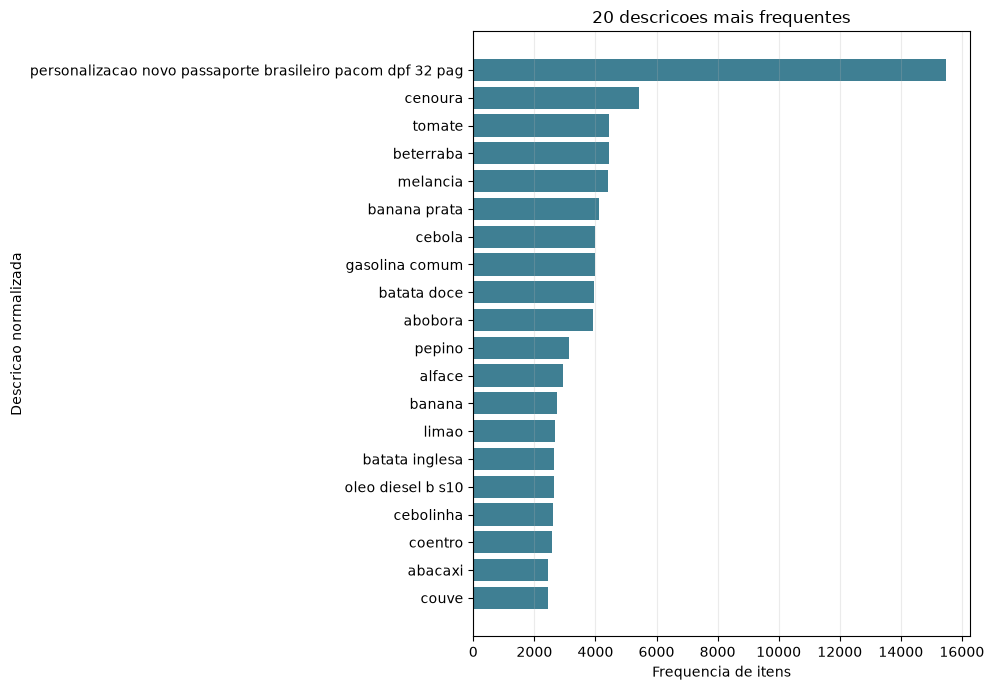

In [48]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_data = top_descriptions.sort_values("frequencia")
ax.barh(plot_data["descricao_normalizada"], plot_data["frequencia"], color="#3f7f93")
ax.set_title("20 descricoes mais frequentes")
ax.set_xlabel("Frequencia de itens")
ax.set_ylabel("Descricao normalizada")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()

## Distribuicao de frequencia das descricoes

In [49]:
frequency_summary = df_descriptions["frequencia"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).to_frame("frequencia")

frequency_bands = pd.cut(
    df_descriptions["frequencia"],
    bins=[0, 1, 2, 5, 10, 50, 100, 500, 1_000, float("inf")],
    labels=["1", "2", "3-5", "6-10", "11-50", "51-100", "101-500", "501-1000", ">1000"],
    right=True,
)

frequency_distribution = (
    frequency_bands.value_counts(sort=False)
    .rename_axis("faixa_frequencia")
    .reset_index(name="descricoes_unicas")
)
frequency_distribution["proporcao_descricoes_unicas"] = (
    frequency_distribution["descricoes_unicas"] / len(df_descriptions)
)

display(frequency_summary)
frequency_distribution

,frequencia
count,466284.000000
mean,3.784807
std,39.684468
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
90%,5.000000
95%,9.000000
99%,41.000000


,faixa_frequencia,descricoes_unicas,proporcao_descricoes_unicas
0,1,299159,0.641581
1,2,75017,0.160883
2,3-5,52475,0.112539
3,6-10,19145,0.041059
4,11-50,16773,0.035972
5,51-100,2275,0.004879
6,101-500,1263,0.002709
7,501-1000,98,0.000210
8,>1000,79,0.000169


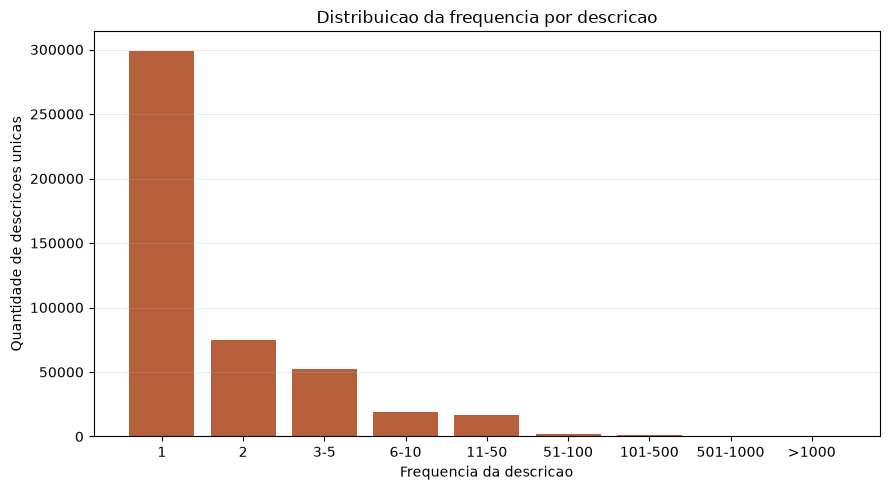

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    frequency_distribution["faixa_frequencia"].astype(str),
    frequency_distribution["descricoes_unicas"],
    color="#b65f3a",
)
ax.set_title("Distribuicao da frequencia por descricao")
ax.set_xlabel("Frequencia da descricao")
ax.set_ylabel("Quantidade de descricoes unicas")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

## Exemplos de ruido

A tabela abaixo usa heuristicas simples para levantar descricoes potencialmente ruidosas: muito curtas, apenas numeros, muitos digitos, sinais de truncamento/codificacao ou muitos caracteres nao alfanumericos.

In [51]:
def noise_reasons(text: object) -> list[str]:
    value = "" if pd.isna(text) else str(text).strip()
    compact = re.sub(r"\s+", "", value)
    reasons = []

    if not value:
        reasons.append("vazia")
    if 0 < len(value) <= 3:
        reasons.append("muito_curta")
    if compact.isdigit():
        reasons.append("apenas_numeros")
    if sum(char.isdigit() for char in value) >= 5:
        reasons.append("muitos_digitos")
    if any(marker in value.lower() for marker in ["�", "??", "***", "xxx", "diversos"]):
        reasons.append("marcador_ruido")
    if value and sum(not char.isalnum() and not char.isspace() for char in value) / len(value) > 0.25:
        reasons.append("muitos_simbolos")

    return reasons


noise_candidates = df_descriptions.copy()
noise_candidates["motivos_ruido"] = noise_candidates["descricao_original_exemplo"].map(noise_reasons)
noise_examples = (
    noise_candidates[noise_candidates["motivos_ruido"].map(bool)]
    .assign(motivos_ruido=lambda frame: frame["motivos_ruido"].map(", ".join))
    .sort_values("frequencia", ascending=False)
    [
        [
            "descricao_original_exemplo",
            "descricao_normalizada",
            "frequencia",
            "motivos_ruido",
            "ncm_tipo_mais_frequente",
        ]
    ]
    .head(30)
)

noise_examples

,descricao_original_exemplo,descricao_normalizada,frequencia,motivos_ruido,ncm_tipo_mais_frequente
21,Papel A4 BR Go Office 75g 500fl CertFSCMisto70% CU COC855709,papel a4 br go office 75g 500fl certfscmisto70 cu coc855709,2230,muitos_digitos,"Outros papéis e cartões,sem fibras obtidas por processo mecânico ou químico-mecânico ou em que a percentagem destas ..."
44,HP CARTUCHO DE TONER PRETO 23.000 PAGINAS,hp cartucho de toner preto 23 000 paginas,1460,muitos_digitos,Cartuchos de revelador (toners)
78,INFUSOMAT COMPACT 100 240V,infusomat compact 100 240v,1008,muitos_digitos,Outros instrumentos e aparelhos para transfusão de sangue ou infusão intravenosa
80,HP E52645DN MFP LASER MONO 48PPM A4,hp e52645dn mfp laser mono 48ppm a4,998,muitos_digitos,"Impressora a laser, LED (Diodos Emissores de Luz) ou LCS (Sistema de Cristal Líquido), monocromáticas, com largura d..."
81,TRANSFORMADOR 1.1KVA 220V PARA 110V 10A TRAVA,transformador 1 1kva 220v para 110v 10a trava,987,muitos_digitos,Outros transformadores elétricos de potência inferior ou igual a 3 kVA
93,5076-58 -ELETRODO CAPSURE FIX NOVUS 5076 58CM MRI SURESCAN,5076 58 eletrodo capsure fix novus 5076 58cm mri surescan,815,muitos_digitos,Partes e acessórios de marca-passos cardíacos
96,HP E52645C MFP LASER MONO 48PPM A4 FLOW,hp e52645c mfp laser mono 48ppm a4 flow,788,muitos_digitos,"Impressora a laser, LED (Diodos Emissores de Luz) ou LCS (Sistema de Cristal Líquido), monocromáticas, com largura d..."
98,"ONU 1075,GAS LIQUEFEITO PETROLEO (GRANEL),2.1",onu 1075 gas liquefeito petroleo granel 2 1,781,muitos_digitos,Gás liquefeito de petróleo (glp)
100,PAPEL A4 75G 500FLS AUTOPAPER (EMBALAGEM AZUL) FSC CREDITO MISTO CERTIFICADO CU-COC-816590,papel a4 75g 500fls autopaper embalagem azul fsc credito misto certificado cu coc 816590,772,muitos_digitos,"Outros papéis e cartões,sem fibras obtidas por processo mecânico ou químico-mecânico ou em que a percentagem destas ..."
104,5076-52 #ELETRODO CAPSURE FIX NOVUS 5076 52CM MRI SURESCAN,5076 52 eletrodo capsure fix novus 5076 52cm mri surescan,718,muitos_digitos,Partes e acessórios de marca-passos cardíacos


## Principais NCMs

In [52]:
top_ncms = (
    df_descriptions.dropna(subset=["codigo_ncm_mais_frequente"])
    .groupby(["codigo_ncm_mais_frequente", "ncm_tipo_mais_frequente"], dropna=False, as_index=False)
    .agg(
        frequencia_total=("frequencia", "sum"),
        descricoes_unicas=("descricao_normalizada", "size"),
    )
    .sort_values("frequencia_total", ascending=False)
    .head(20)
)

top_ncms

,codigo_ncm_mais_frequente,ncm_tipo_mais_frequente,frequencia_total,descricoes_unicas
4249,49019900.0,"Outros livros, brochuras e impressos semelhantes",158121,26310
7960,90189099.0,"Outros instrumentos e aparelhos para medicina, cirurgia, etc",95750,15519
7970,90211020.0,Artigos e aparelhos para fraturas,53517,15557
7976,90213190.0,Outras próteses articulares,23867,3889
676,7099990.0,"Outros produtos hortícolas, frescos ou refrigerados",22822,613
3228,38221990.0,NaN,21406,8365
7921,90183929.0,"Outras sondas, catéteres e cânulas",19939,5027
4268,49119900.0,Outros impressos,16949,458
6370,84439933.0,Cartuchos de revelador (toners),15022,2231
7975,90213110.0,Próteses articulares femurais,14931,2307


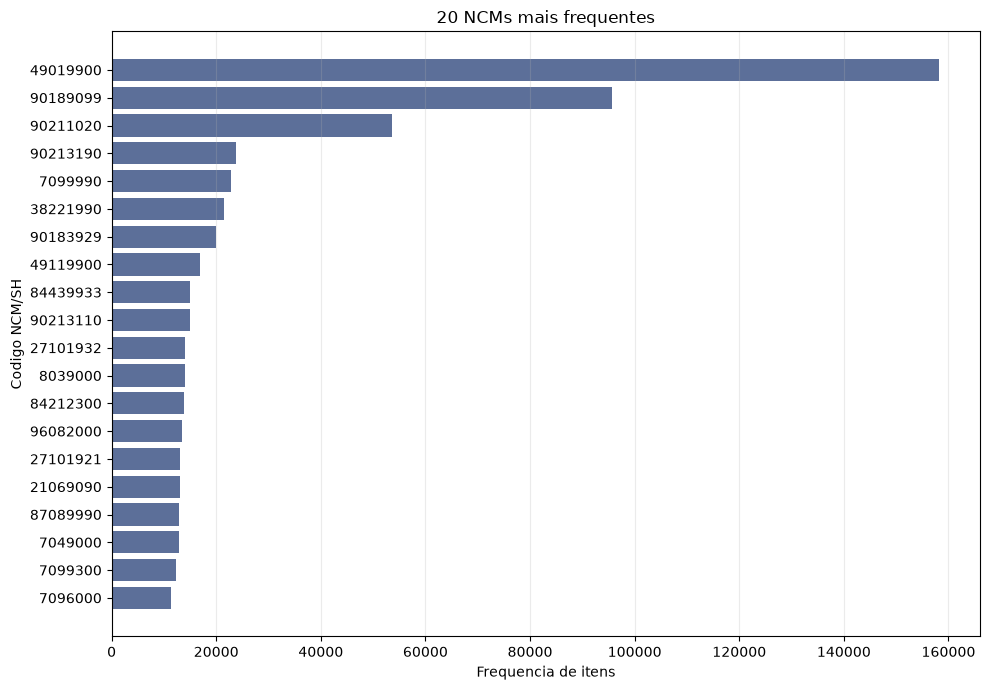

In [53]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_data = top_ncms.sort_values("frequencia_total")
labels = plot_data["codigo_ncm_mais_frequente"].astype("Int64").astype(str)
ax.barh(labels, plot_data["frequencia_total"], color="#5c6f99")
ax.set_title("20 NCMs mais frequentes")
ax.set_xlabel("Frequencia de itens")
ax.set_ylabel("Codigo NCM/SH")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()

## Volume por mes

In [54]:
monthly_volume = (
    df_monthly.groupby("competencia", as_index=False)
    .agg(
        total_itens=("descricao_original", "size"),
        descricoes_validas=("descricao_original", lambda series: series.fillna("").astype(str).str.strip().ne("").sum()),
        descricoes_unicas_originais=("descricao_original", lambda series: series.dropna().astype(str).str.strip().nunique()),
    )
)
monthly_volume["proporcao_descricoes_unicas"] = (
    monthly_volume["descricoes_unicas_originais"] / monthly_volume["total_itens"]
)

monthly_volume

,competencia,total_itens,descricoes_validas,descricoes_unicas_originais,proporcao_descricoes_unicas
0,2025-01,478562,369683,151264,0.316080
1,2025-02,608847,490657,168972,0.277528
2,2025-03,551362,434549,157817,0.286231
3,2025-04,598767,470126,171220,0.285954


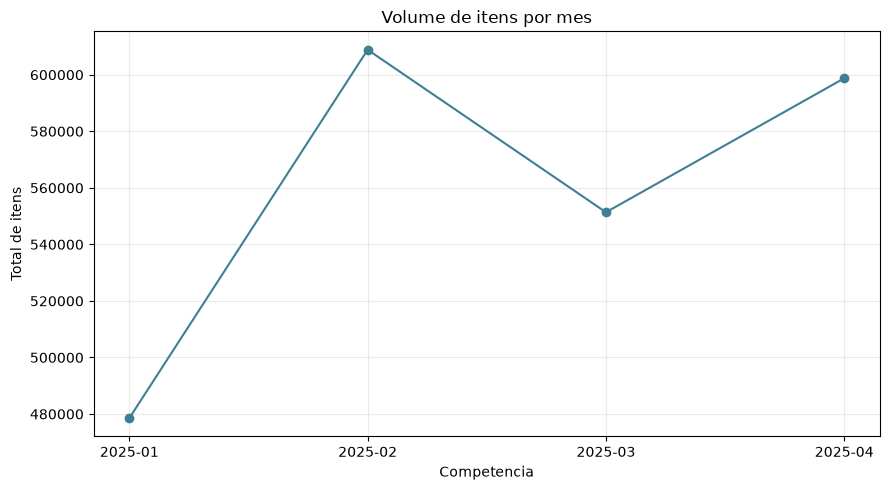

In [55]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_volume["competencia"], monthly_volume["total_itens"], marker="o", color="#3f7f93")
ax.set_title("Volume de itens por mes")
ax.set_xlabel("Competencia")
ax.set_ylabel("Total de itens")
ax.grid(alpha=0.25)
fig.tight_layout()

## Proporcao de descricoes unicas versus total de itens

In [56]:
overall_unique_ratio = pd.DataFrame(
    [
        {
            "escopo": "base_processada_2025_01_a_2025_04",
            "total_itens": int(df_descriptions["frequencia"].sum()),
            "descricoes_unicas_normalizadas": len(df_descriptions),
            "proporcao_unicas_sobre_total": len(df_descriptions) / df_descriptions["frequencia"].sum(),
        }
    ]
)

display(overall_unique_ratio)
monthly_volume[["competencia", "total_itens", "descricoes_unicas_originais", "proporcao_descricoes_unicas"]]

,escopo,total_itens,descricoes_unicas_normalizadas,proporcao_unicas_sobre_total
0,base_processada_2025_01_a_2025_04,1764795,466284,0.264214


,competencia,total_itens,descricoes_unicas_originais,proporcao_descricoes_unicas
0,2025-01,478562,151264,0.316080
1,2025-02,608847,168972,0.277528
2,2025-03,551362,157817,0.286231
3,2025-04,598767,171220,0.285954


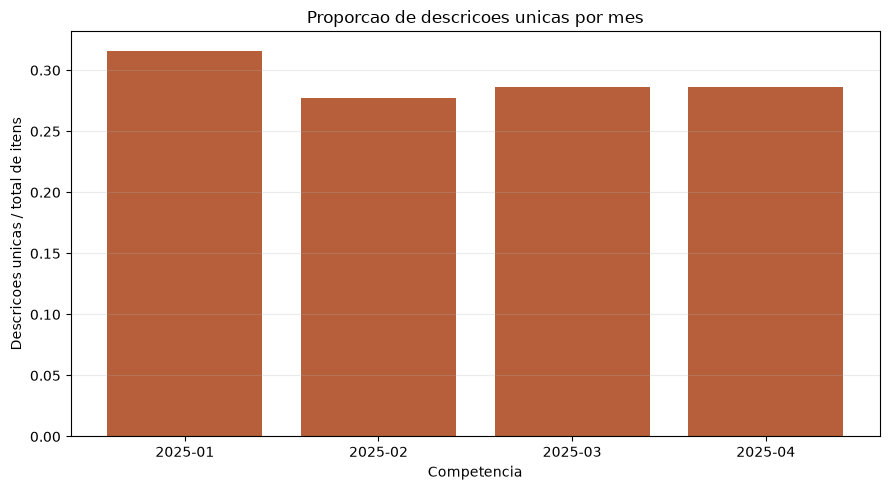

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    monthly_volume["competencia"],
    monthly_volume["proporcao_descricoes_unicas"],
    color="#b65f3a",
)
ax.set_title("Proporcao de descricoes unicas por mes")
ax.set_xlabel("Competencia")
ax.set_ylabel("Descricoes unicas / total de itens")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

## Variaveis fiscais e de emissao

As secoes abaixo analisam separadamente as colunas fiscais e de emissao carregadas da base intermediaria.


In [58]:
def summarize_categorical_column(column: str) -> pd.DataFrame:
    """Summarize missingness, cardinality and the most frequent value of a categorical column."""
    values = clean_categorical_series(df_monthly[column])
    return pd.DataFrame(
        [
            {
                "coluna": FISCAL_COLUMN_LABELS[column],
                "total_itens": len(values),
                "valores_ausentes": int(values.isna().sum()),
                "proporcao_ausente": values.isna().mean(),
                "valores_distintos": int(values.nunique(dropna=True)),
                "valor_mais_frequente": values.mode(dropna=True).iat[0] if values.notna().any() else pd.NA,
            }
        ]
    )


def top_categorical_values(column: str, limit: int = 15) -> pd.DataFrame:
    """Return the most frequent values of a categorical column."""
    values = clean_categorical_series(df_monthly[column]).fillna("<ausente>")
    return (
        values.value_counts(dropna=False)
        .head(limit)
        .rename_axis("valor")
        .reset_index(name="total_itens")
        .assign(
            coluna=FISCAL_COLUMN_LABELS[column],
            proporcao=lambda frame: frame["total_itens"] / len(df_monthly),
        )
        [["coluna", "valor", "total_itens", "proporcao"]]
    )


def plot_top_categorical_values(column: str, limit: int = 10, color: str = "#3f7f93") -> None:
    """Plot the most frequent values of a categorical column."""
    plot_data = top_categorical_values(column, limit=limit).sort_values("total_itens")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(plot_data["valor"].astype(str), plot_data["total_itens"], color=color)
    ax.set_title(f"Valores mais frequentes - {FISCAL_COLUMN_LABELS[column]}")
    ax.set_xlabel("Total de itens")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()


## SÉRIE


In [59]:
serie_summary = summarize_categorical_column("serie")
serie_top_values = top_categorical_values("serie")

display(serie_summary)
serie_top_values


,coluna,total_itens,valores_ausentes,proporcao_ausente,valores_distintos,valor_mais_frequente
0,SÉRIE,2237538,0,0.0,359,1


,coluna,valor,total_itens,proporcao
0,SÉRIE,1,1477754,0.660437
1,SÉRIE,2,186489,0.083346
2,SÉRIE,4,108560,0.048518
3,SÉRIE,0,101342,0.045292
4,SÉRIE,890,88576,0.039586
5,SÉRIE,3,85551,0.038234
6,SÉRIE,5,33348,0.014904
7,SÉRIE,100,15553,0.006951
8,SÉRIE,891,12677,0.005666
9,SÉRIE,7,12533,0.005601


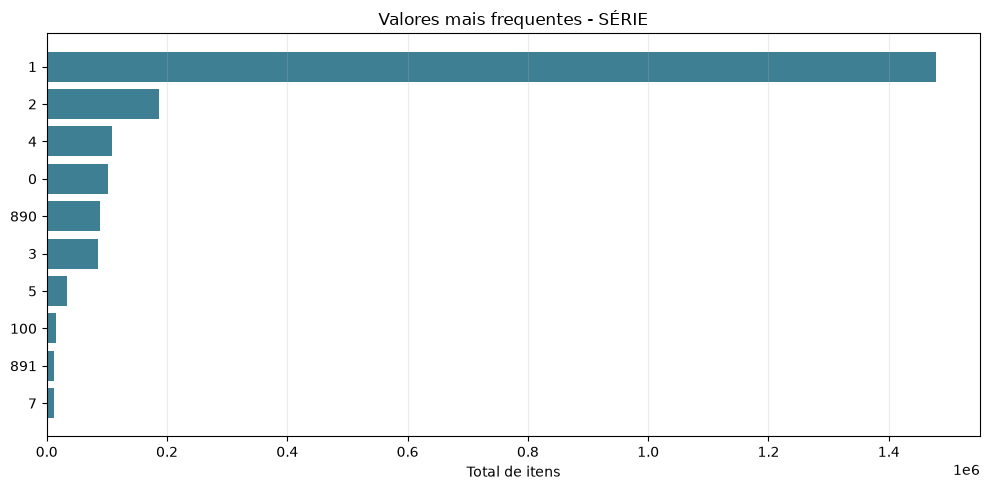

In [60]:
plot_top_categorical_values("serie", color="#3f7f93")


## NATUREZA DA OPERAÇÃO


In [61]:
natureza_operacao_summary = summarize_categorical_column("natureza_operacao")
natureza_operacao_top_values = top_categorical_values("natureza_operacao")

display(natureza_operacao_summary)
natureza_operacao_top_values


,coluna,total_itens,valores_ausentes,proporcao_ausente,valores_distintos,valor_mais_frequente
0,NATUREZA DA OPERAÇÃO,2237538,0,0.0,13805,VENDA


,coluna,valor,total_itens,proporcao
0,NATUREZA DA OPERAÇÃO,VENDA,116992,0.052286
1,NATUREZA DA OPERAÇÃO,Outra saida merc. prest. serv. nao especificado,86273,0.038557
2,NATUREZA DA OPERAÇÃO,RETORNO SIMBOLICO DE MERCADORIA DEPOSITADA EM DEPOSITO FECHA,84884,0.037936
3,NATUREZA DA OPERAÇÃO,Venda,82197,0.036735
4,NATUREZA DA OPERAÇÃO,VENDA DE MERCADORIA,78491,0.035079
5,NATUREZA DA OPERAÇÃO,VENDA DE MERCADORIA ADQUIRIDA OU RECEBIDA DE TERCEIROS,47285,0.021133
6,NATUREZA DA OPERAÇÃO,Venda de mercadoria adquirida ou recebida de terceiros,44689,0.019972
7,NATUREZA DA OPERAÇÃO,Venda de mercadoria,40216,0.017973
8,NATUREZA DA OPERAÇÃO,OUTRAS SAIDAS,35969,0.016075
9,NATUREZA DA OPERAÇÃO,SIMPLES REMESSA,29769,0.013304


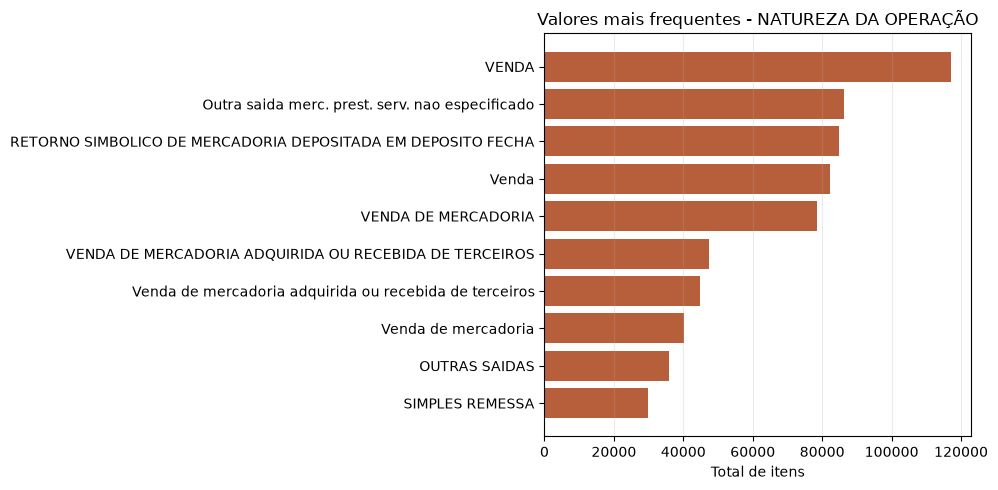

In [62]:
plot_top_categorical_values("natureza_operacao", color="#b65f3a")


## RAZÃO SOCIAL EMITENTE


In [63]:
razao_social_emitente_summary = summarize_categorical_column("razao_social_emitente")
razao_social_emitente_top_values = top_categorical_values("razao_social_emitente")

display(razao_social_emitente_summary)
razao_social_emitente_top_values


,coluna,total_itens,valores_ausentes,proporcao_ausente,valores_distintos,valor_mais_frequente
0,RAZÃO SOCIAL EMITENTE,2237538,0,0.0,45351,EMPRES BRASILEIRA DE CORREIOS E TELEGRAFOS


,coluna,valor,total_itens,proporcao
0,RAZÃO SOCIAL EMITENTE,EMPRES BRASILEIRA DE CORREIOS E TELEGRAFOS,85605,0.038259
1,RAZÃO SOCIAL EMITENTE,BRS SUPRIMENTOS CORPORATIVOS S/A,83724,0.037418
2,RAZÃO SOCIAL EMITENTE,ENDOLOG LOGISTICA E ARMAZENS LTDA,53046,0.023707
3,RAZÃO SOCIAL EMITENTE,AUTOPEL AUTOMACAO COMERCIAL E INFORMATICA LTDA.,33838,0.015123
4,RAZÃO SOCIAL EMITENTE,CASA DA MOEDA DO BRASIL,30264,0.013526
5,RAZÃO SOCIAL EMITENTE,TRAUMINAS DIST MAT CIRURG HOSP LTDA,24415,0.010912
6,RAZÃO SOCIAL EMITENTE,SIMPRESS COMERCIO LOCACAO E SERVICOS LTDA,19972,0.008926
7,RAZÃO SOCIAL EMITENTE,BIO 2 IMP. E COM DE MAT. MED. HOSP. LTDA,17382,0.007768
8,RAZÃO SOCIAL EMITENTE,EDITORA FTD S.A.,13578,0.006068
9,RAZÃO SOCIAL EMITENTE,REFISERVI REFEICOES INDUSTRIAIS LTDA,12641,0.00565


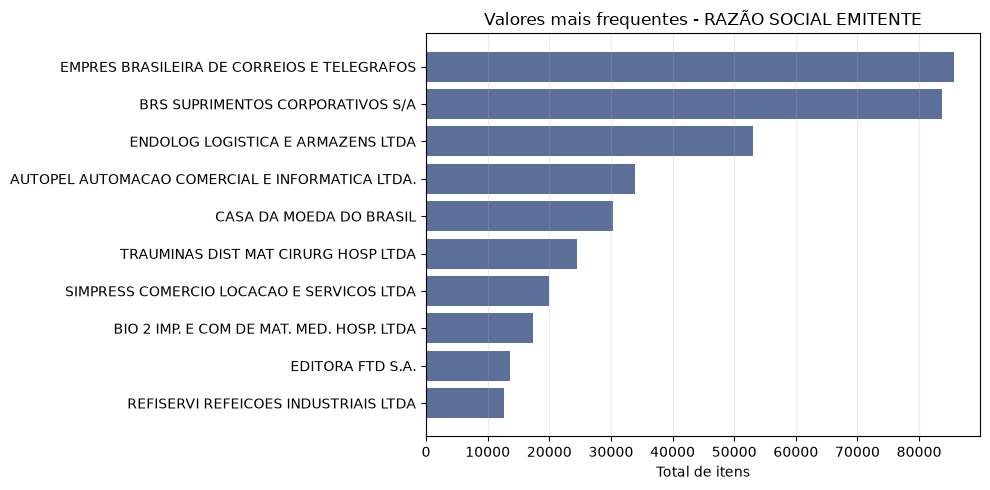

In [64]:
plot_top_categorical_values("razao_social_emitente", color="#5c6f99")


In [65]:
top_emitters_by_month = (
    df_monthly.assign(
        razao_social_emitente=clean_categorical_series(df_monthly["razao_social_emitente"]).fillna("<ausente>")
    )
    .groupby(["competencia", "razao_social_emitente"], as_index=False)
    .agg(total_itens=("descricao_original", "size"))
    .sort_values(["competencia", "total_itens"], ascending=[True, False])
    .groupby("competencia", as_index=False)
    .head(10)
)

top_emitters_by_month


,competencia,razao_social_emitente,total_itens
3106,2025-01,BRS SUPRIMENTOS CORPORATIVOS S/A,11644
6340,2025-01,ENDOLOG LOGISTICA E ARMAZENS LTDA,10261
3492,2025-01,CASA DA MOEDA DO BRASIL,8617
6314,2025-01,EMPRES BRASILEIRA DE CORREIOS E TELEGRAFOS,7600
9787,2025-01,JUSIMED IMP E COM PRODUTOS MEDICOS LTDA,5761
2440,2025-01,AUTOPEL AUTOMACAO COMERCIAL E INFORMATICA LTDA.,5712
16824,2025-01,TRAUMINAS DIST MAT CIRURG HOSP LTDA,4903
15833,2025-01,SIMPRESS COMERCIO LOCACAO E SERVICOS LTDA,4752
5875,2025-01,EDITORA FTD S.A.,3871
6992,2025-01,FIEIS DA TERRA ATACADISTA LTDA,2672


## CONSUMIDOR FINAL


In [66]:
consumidor_final_summary = summarize_categorical_column("consumidor_final")
consumidor_final_top_values = top_categorical_values("consumidor_final")

display(consumidor_final_summary)
consumidor_final_top_values


,coluna,total_itens,valores_ausentes,proporcao_ausente,valores_distintos,valor_mais_frequente
0,CONSUMIDOR FINAL,2237538,0,0.0,2,1 - CONSUMIDOR FINAL


,coluna,valor,total_itens,proporcao
0,CONSUMIDOR FINAL,1 - CONSUMIDOR FINAL,1925730,0.860647
1,CONSUMIDOR FINAL,0 - NORMAL,311808,0.139353


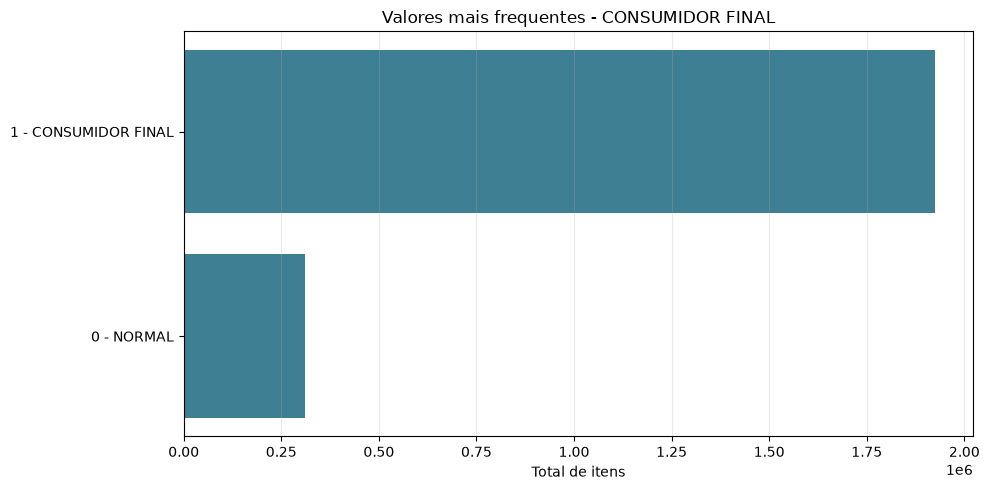

In [67]:
plot_top_categorical_values("consumidor_final", color="#3f7f93")


## PRESENÇA DO COMPRADOR


In [68]:
presenca_comprador_summary = summarize_categorical_column("presenca_comprador")
presenca_comprador_top_values = top_categorical_values("presenca_comprador")

display(presenca_comprador_summary)
presenca_comprador_top_values


,coluna,total_itens,valores_ausentes,proporcao_ausente,valores_distintos,valor_mais_frequente
0,PRESENÇA DO COMPRADOR,2237538,0,0.0,6,"9 - OPERAÇÃO NÃO PRESENCIAL, OUTROS"


,coluna,valor,total_itens,proporcao
0,PRESENÇA DO COMPRADOR,"9 - OPERAÇÃO NÃO PRESENCIAL, OUTROS",792417,0.354147
1,PRESENÇA DO COMPRADOR,0 - NÃO SE APLICA,729791,0.326158
2,PRESENÇA DO COMPRADOR,1 - OPERAÇÃO PRESENCIAL,609981,0.272613
3,PRESENÇA DO COMPRADOR,"2 - OPERAÇÃO NÃO PRESENCIAL, PELA INTERNET",52673,0.023541
4,PRESENÇA DO COMPRADOR,"3 - OPERAÇÃO NÃO PRESENCIAL, TELEATENDIMENTO",46196,0.020646
5,PRESENÇA DO COMPRADOR,5 - NÃO INFORMADO,6480,0.002896


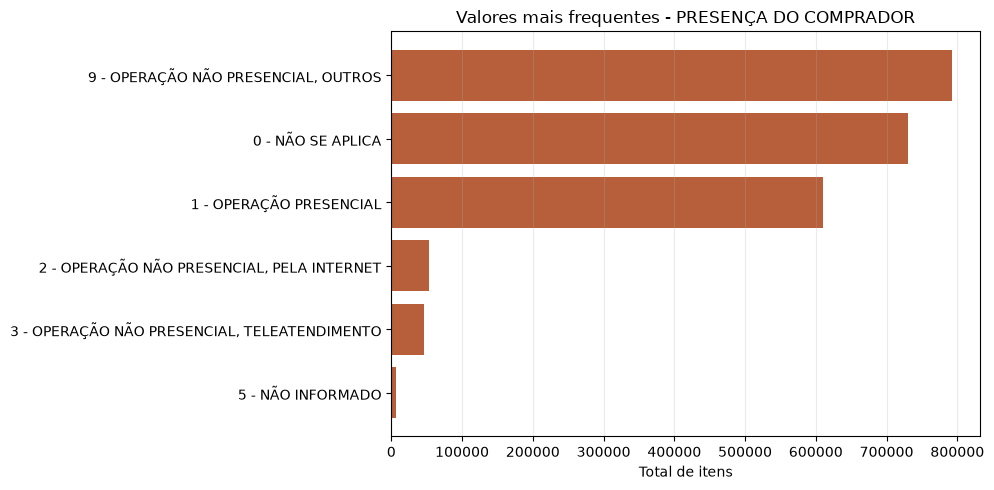

In [69]:
plot_top_categorical_values("presenca_comprador", color="#b65f3a")


In [70]:
consumer_presence_cross = pd.crosstab(
    clean_categorical_series(df_monthly["consumidor_final"]).fillna("<ausente>"),
    clean_categorical_series(df_monthly["presenca_comprador"]).fillna("<ausente>"),
    margins=True,
)
consumer_presence_cross.index.name = "CONSUMIDOR FINAL"
consumer_presence_cross.columns.name = "PRESENÇA DO COMPRADOR"
consumer_presence_cross


PRESENÇA DO COMPRADOR,0 - NÃO SE APLICA,1 - OPERAÇÃO PRESENCIAL,"2 - OPERAÇÃO NÃO PRESENCIAL, PELA INTERNET","3 - OPERAÇÃO NÃO PRESENCIAL, TELEATENDIMENTO",5 - NÃO INFORMADO,"9 - OPERAÇÃO NÃO PRESENCIAL, OUTROS",All
CONSUMIDOR FINAL,,,,,,,
0 - NORMAL,118149,96709,8441,9072,349,79088,311808
1 - CONSUMIDOR FINAL,611642,513272,44232,37124,6131,713329,1925730
All,729791,609981,52673,46196,6480,792417,2237538


## Leituras para a metodologia

- As descricoes mais frequentes indicam quais termos dominam a base e podem influenciar vetorizacao e clusterizacao.
- A distribuicao de frequencia ajuda a justificar filtros como frequencia minima ou tratamento separado para cauda longa.
- Os exemplos de ruido mostram limites da normalizacao textual e pontos que podem exigir revisao manual.
- Os NCMs mais frequentes podem apoiar a interpretacao dos clusters, mas nao devem ser tratados automaticamente como rotulos finais.
- O volume mensal e a proporcao de descricoes unicas ajudam a descrever a cobertura temporal da base no texto do TCC.